In [ ]:
!pip install -q paddleocr paddlepaddle pytesseract pdf2image pandas jiwer


In [ ]:
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr tesseract-ocr-eng tesseract-ocr-ara

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import paddle
import paddleocr
import pytesseract

print("PaddlePaddle:", paddle.__version__)
print("PaddleOCR:", paddleocr.__version__)
print("Tesseract:", pytesseract.get_tesseract_version())
print("Tesseract languages:", pytesseract.get_languages())

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle: 3.3.1
PaddleOCR: 3.7.0
Tesseract: 4.1.1
Tesseract languages: ['ara', 'eng', 'osd']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Week1_OCR_Sample_PDFs.zip to Week1_OCR_Sample_PDFs (1).zip


In [ ]:
import zipfile
import os

zip_path = "Week1_OCR_Sample_PDFs.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("week1_ocr_samples")

print("Files extracted successfully!")

Files extracted successfully!


In [ ]:
import os

for file in os.listdir("week1_ocr_samples"):
    print(file)

06_scanned_style.pdf
01_english.pdf
05_table.pdf
ground_truth.txt
04_layout.pdf
02_arabic.pdf
03_mixed.pdf


In [ ]:
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

pdf_path = "week1_ocr_samples/01_english.pdf"

images = convert_from_path(
    pdf_path,
    dpi=200
)

print("Number of pages:", len(images))

Number of pages: 1


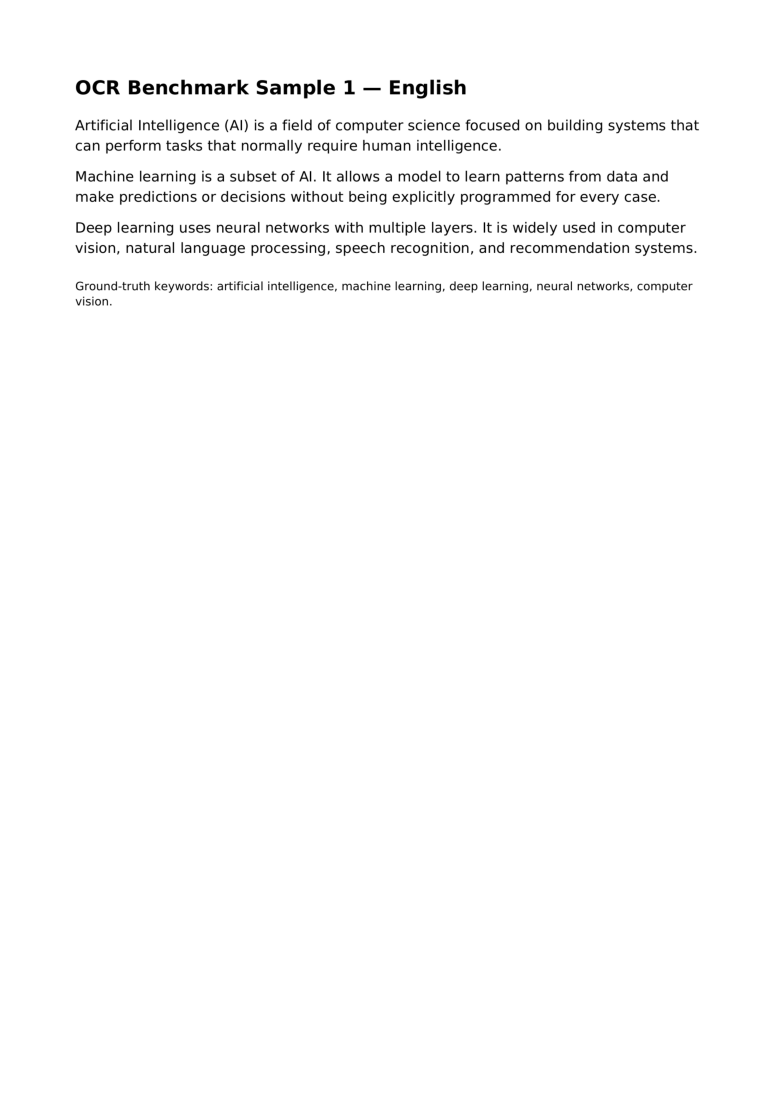

In [ ]:
plt.figure(figsize=(10, 14))
plt.imshow(images[0])
plt.axis("off")
plt.show()

In [ ]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    lang="en",
    device="cpu",
    enable_mkldnn=False
)

print("PaddleOCR initialized successfully!")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP

PaddleOCR initialized successfully!


In [ ]:
print("Image type:", type(images[0]))
print("Image size:", images[0].size)

import numpy as np

img = np.array(images[0])

print("Image shape:", img.shape)
print("Image dtype:", img.dtype)

print("\nResult type:", type(result))
print("Result:", result)

Image type: <class 'PIL.PpmImagePlugin.PpmImageFile'>
Image size: (1654, 2339)
Image shape: (2339, 1654, 3)
Image dtype: uint8

Result type: <class 'list'>
Result: []


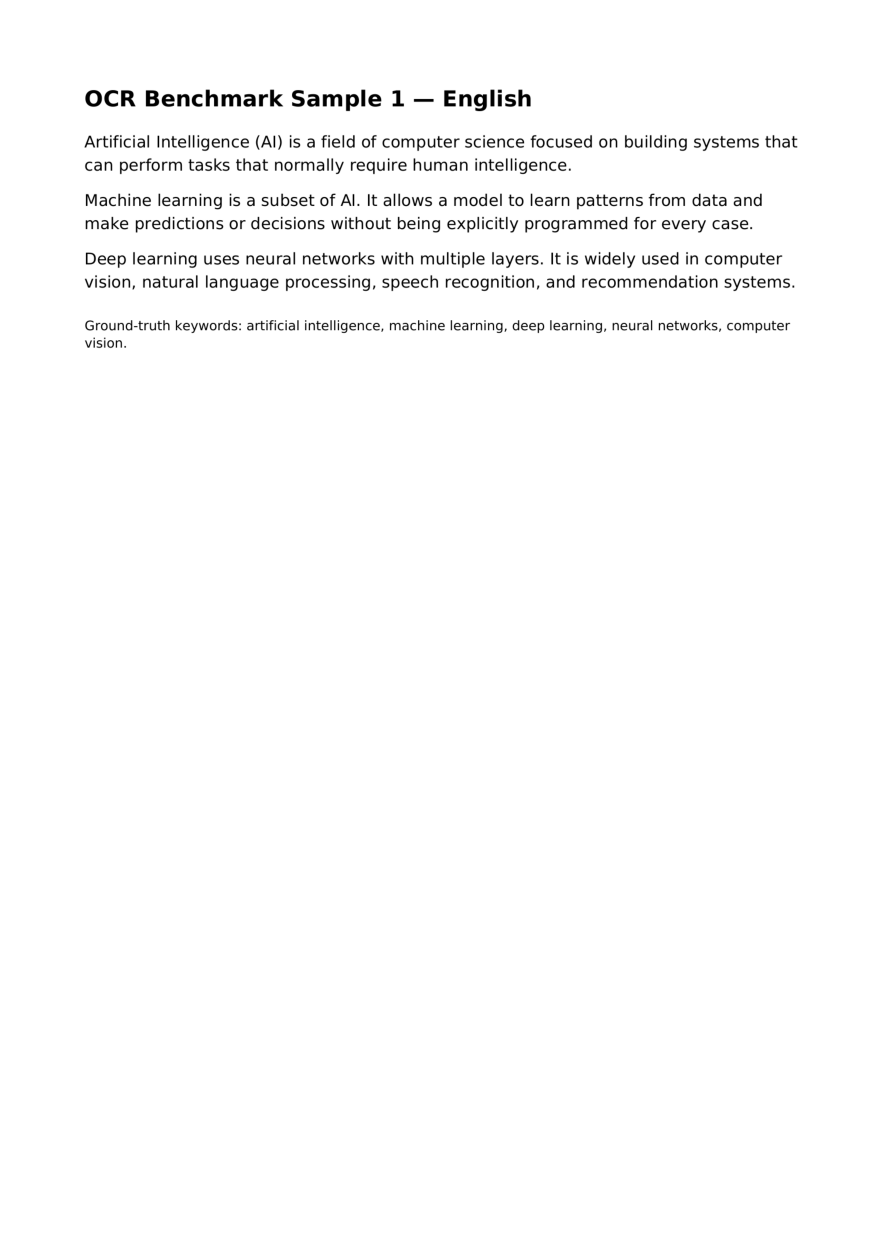

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 16))
plt.imshow(images[0])
plt.axis("off")
plt.show()

In [ ]:
# Save the PDF page as an image
image_path = "week1_ocr_samples/page1.png"

images[0].save(image_path)

print("Image saved:", image_path)

Image saved: week1_ocr_samples/page1.png


In [ ]:
# Run PaddleOCR using the image PATH
result = ocr.predict(
    input=image_path
)

print("Result type:", type(result))
print("Number of results:", len(result))

Result type: <class 'list'>
Number of results: 1


In [ ]:
res = result[0]

print("Available attributes:")
print([x for x in dir(res) if not x.startswith("_")])

Available attributes:
['clear', 'copy', 'fromkeys', 'get', 'img', 'items', 'json', 'keys', 'pop', 'popitem', 'print', 'save_all', 'save_to_img', 'save_to_json', 'setdefault', 'str', 'update', 'values']


In [ ]:
data = result[0]

print("Keys:")
print(data.keys())

Keys:
dict_keys(['input_path', 'page_index', 'doc_preprocessor_res', 'dt_polys', 'model_settings', 'text_det_params', 'text_type', 'text_rec_score_thresh', 'return_word_box', 'rec_texts', 'rec_scores', 'rec_polys', 'vis_fonts', 'textline_orientation_angles', 'rec_boxes'])


In [ ]:
texts = data["rec_texts"]

print("Detected text:\n")

for text in texts:
    print(text)

Detected text:

OCR Benchmark Sample 1 — English
Artificial Intelligence (Al) is a field of computer science focused on building systems that
can perform tasks that normally require human intelligence.
Machine learning is a subset of Al. It allows a model to learn patterns from data and
make predictions or decisions without being explicitly programmed for every case.
Deep learning uses neural networks with multiple layers. It is widely used in computer
vision, natural language processing, speech recognition, and recommendation systems.
vision.


In [ ]:
# Get OCR result
data = result[0]

# Extract recognized text
texts = data["rec_texts"]

print("===== PaddleOCR TEXT =====\n")

paddle_text = ""

for text in texts:
    print(text)
    paddle_text += text + "\n"

print("\n===== END =====")

===== PaddleOCR TEXT =====

OCR Benchmark Sample 1 — English
Artificial Intelligence (Al) is a field of computer science focused on building systems that
can perform tasks that normally require human intelligence.
Machine learning is a subset of Al. It allows a model to learn patterns from data and
make predictions or decisions without being explicitly programmed for every case.
Deep learning uses neural networks with multiple layers. It is widely used in computer
vision, natural language processing, speech recognition, and recommendation systems.
vision.

===== END =====


In [ ]:
with open(
    "paddleocr_01_english.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(paddle_text)

print("PaddleOCR result saved successfully!")

PaddleOCR result saved successfully!


In [ ]:
import pytesseract
import time

start = time.perf_counter()

tesseract_text = pytesseract.image_to_string(
    images[0],
    lang="eng"
)

tesseract_time = time.perf_counter() - start

print("===== Tesseract TEXT =====\n")
print(tesseract_text)

print("\nProcessing time:")
print(f"{tesseract_time:.4f} seconds")

===== Tesseract TEXT =====

OCR Benchmark Sample 1 — English

Artificial Intelligence (Al) is a field of computer science focused on building systems that
can perform tasks that normally require human intelligence.

Machine learning is a subset of Al. It allows a model to learn patterns from data and
make predictions or decisions without being explicitly programmed for every case.

Deep learning uses neural networks with multiple layers. It is widely used in computer
vision, natural language processing, speech recognition, and recommendation systems.

Ground-truth keywords: artificial intelligence, machine learning, deep learning, neural networks, computer
vision.


Processing time:
5.1907 seconds


In [ ]:
start = time.perf_counter()

result = ocr.predict(
    input=image_path
)

paddle_time = time.perf_counter() - start

print(f"PaddleOCR time: {paddle_time:.4f} seconds")

PaddleOCR time: 77.6003 seconds


In [ ]:
ground_truth_path = "week1_ocr_samples/ground_truth.txt"

with open(ground_truth_path, "r", encoding="utf-8") as f:
    gt = f.read()

print(gt[:1000])

OCR Benchmark Ground Truth

01_english.pdf
Artificial Intelligence (AI) is a field of computer science focused on building systems that can perform tasks that normally require human intelligence.
Machine learning is a subset of AI. It allows a model to learn patterns from data and make predictions or decisions without being explicitly programmed for every case.
Deep learning uses neural networks with multiple layers. It is widely used in computer vision, natural language processing, speech recognition, and recommendation systems.

02_arabic.pdf
الذكاء الاصطناعي هو أحد فروع علوم الحاسب، ويهدف إلى بناء أنظمة قادرة على تنفيذ مهام تتطلب عادةً قدرات بشرية.
تعلم الآلة هو فرع من الذكاء الاصطناعي، حيث يتعلم النموذج الأنماط من البيانات ثم يستخدمها لإجراء التنبؤات أو اتخاذ القرارات.
يستخدم التعلم العميق الشبكات العصبية متعددة الطبقات في تطبيقات مثل رؤية الحاسب ومعالجة اللغة الطبيعية والتعرف على الكلام.

03_mixed.pdf
OpenLearn AI uses Retrieval-Augmented Generation (RAG) to answer student questio

In [ ]:
import re

with open(
    "week1_ocr_samples/ground_truth.txt",
    "r",
    encoding="utf-8"
) as f:
    gt_file = f.read()

match = re.search(
    r"01_english\.pdf\n(.*?)(?=\n\n02_arabic\.pdf)",
    gt_file,
    re.DOTALL
)

ground_truth = match.group(1).strip()

print("===== GROUND TRUTH =====")
print(ground_truth)

===== GROUND TRUTH =====
Artificial Intelligence (AI) is a field of computer science focused on building systems that can perform tasks that normally require human intelligence.
Machine learning is a subset of AI. It allows a model to learn patterns from data and make predictions or decisions without being explicitly programmed for every case.
Deep learning uses neural networks with multiple layers. It is widely used in computer vision, natural language processing, speech recognition, and recommendation systems.


In [ ]:
from jiwer import cer, wer

paddle_cer = cer(
    ground_truth,
    paddle_text
)

paddle_wer = wer(
    ground_truth,
    paddle_text
)

tesseract_cer = cer(
    ground_truth,
    tesseract_text
)

tesseract_wer = wer(
    ground_truth,
    tesseract_text
)

print("===== RESULTS =====")

print(f"PaddleOCR CER: {paddle_cer:.4f}")
print(f"PaddleOCR WER: {paddle_wer:.4f}")

print()

print(f"Tesseract CER: {tesseract_cer:.4f}")
print(f"Tesseract WER: {tesseract_wer:.4f}")

===== RESULTS =====
PaddleOCR CER: 0.0935
PaddleOCR WER: 0.2113

Tesseract CER: 0.3191
Tesseract WER: 0.4085


In [ ]:
ocr = PaddleOCR(
    lang="en",
    device="cpu",
    enable_mkldnn=False
)

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP

In [ ]:
import os
import time
import re
import pandas as pd
import pytesseract
from jiwer import cer, wer

# ==========================================
# Settings
# ==========================================

PDF_FOLDER = "week1_ocr_samples"

# ملفات الاختبار
pdf_files = [
    "01_english.pdf",
    "02_arabic.pdf",
    "03_mixed.pdf",
    "04_layout.pdf",
    "05_table.pdf",
    "06_scanned_style.pdf"
]

# ==========================================
# Ground Truth
# ==========================================

with open(
    os.path.join(PDF_FOLDER, "ground_truth.txt"),
    "r",
    encoding="utf-8"
) as f:
    gt_file = f.read()


def get_ground_truth(filename):

    pattern = rf"{re.escape(filename)}\n(.*?)(?=\n\n\d{{2}}_[^\n]+\.pdf|\Z)"

    match = re.search(
        pattern,
        gt_file,
        re.DOTALL
    )

    if match:
        return match.group(1).strip()

    return ""


# ==========================================
# PaddleOCR
# ==========================================

def run_paddleocr(image_path):

    start = time.perf_counter()

    result = ocr.predict(
        input=image_path
    )

    elapsed = time.perf_counter() - start

    text = ""

    if len(result) > 0:

        data = result[0]

        try:
            texts = data["rec_texts"]

            text = "\n".join(texts)

        except Exception as e:

            print("Paddle extraction error:", e)

    return text, elapsed


# ==========================================
# Tesseract
# ==========================================

def run_tesseract(image, language):

    start = time.perf_counter()

    text = pytesseract.image_to_string(
        image,
        lang=language
    )

    elapsed = time.perf_counter() - start

    return text, elapsed


# ==========================================
# Benchmark
# ==========================================

results = []


for pdf_file in pdf_files:

    print("\n" + "=" * 60)

    print("Processing:", pdf_file)

    print("=" * 60)


    pdf_path = os.path.join(
        PDF_FOLDER,
        pdf_file
    )


    # --------------------------------------
    # Convert PDF to image
    # --------------------------------------

    from pdf2image import convert_from_path

    images = convert_from_path(
        pdf_path,
        dpi=200
    )


    # --------------------------------------
    # Language selection
    # --------------------------------------

    if pdf_file == "02_arabic.pdf":

        tesseract_lang = "ara"

    elif pdf_file == "03_mixed.pdf":

        tesseract_lang = "ara+eng"

    else:

        tesseract_lang = "eng"


    ground_truth = get_ground_truth(
        pdf_file
    )


    # --------------------------------------
    # Process pages
    # --------------------------------------

    paddle_all_text = ""
    tesseract_all_text = ""

    paddle_total_time = 0
    tesseract_total_time = 0


    for page_number, image in enumerate(images):

        image_path = (
            f"/content/"
            f"temp_{pdf_file}_page_{page_number}.png"
        )

        image.save(image_path)


        # ==============================
        # PaddleOCR
        # ==============================

        paddle_text, paddle_time = run_paddleocr(
            image_path
        )

        paddle_all_text += (
            paddle_text + "\n"
        )

        paddle_total_time += paddle_time


        # ==============================
        # Tesseract
        # ==============================

        tesseract_text, tesseract_time = run_tesseract(
            image,
            tesseract_lang
        )

        tesseract_all_text += (
            tesseract_text + "\n"
        )

        tesseract_total_time += tesseract_time


    # ======================================
    # Evaluation
    # ======================================

    try:

        paddle_cer = cer(
            ground_truth,
            paddle_all_text
        )

        paddle_wer = wer(
            ground_truth,
            paddle_all_text
        )

    except:

        paddle_cer = 1
        paddle_wer = 1


    try:

        tesseract_cer = cer(
            ground_truth,
            tesseract_all_text
        )

        tesseract_wer = wer(
            ground_truth,
            tesseract_all_text
        )

    except:

        tesseract_cer = 1
        tesseract_wer = 1


    # ======================================
    # Save results
    # ======================================

    results.append({

        "PDF": pdf_file,

        "Engine": "PaddleOCR",

        "Language": tesseract_lang,

        "Time_sec":
            round(
                paddle_total_time,
                4
            ),

        "CER":
            round(
                paddle_cer,
                4
            ),

        "WER":
            round(
                paddle_wer,
                4
            ),

        "Character_Accuracy_%":
            round(
                (1 - paddle_cer) * 100,
                2
            )

    })


    results.append({

        "PDF": pdf_file,

        "Engine": "Tesseract",

        "Language": tesseract_lang,

        "Time_sec":
            round(
                tesseract_total_time,
                4
            ),

        "CER":
            round(
                tesseract_cer,
                4
            ),

        "WER":
            round(
                tesseract_wer,
                4
            ),

        "Character_Accuracy_%":
            round(
                (1 - tesseract_cer) * 100,
                2
            )

    })


# ==========================================
# Create DataFrame
# ==========================================

df = pd.DataFrame(results)

print("\n\n")
print("=" * 80)
print("FINAL OCR BENCHMARK")
print("=" * 80)

display(df)


# ==========================================
# Save CSV
# ==========================================

output_file = "ocr_benchmark_results.csv"

df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nSaved:",
    output_file
)


Processing: 01_english.pdf

Processing: 02_arabic.pdf

Processing: 03_mixed.pdf

Processing: 04_layout.pdf

Processing: 05_table.pdf

Processing: 06_scanned_style.pdf



FINAL OCR BENCHMARK


,PDF,Engine,Language,Time_sec,CER,WER,Character_Accuracy_%
0,01_english.pdf,PaddleOCR,eng,73.1654,0.0935,0.2113,90.65
1,01_english.pdf,Tesseract,eng,2.9831,0.3191,0.4085,68.09
2,02_arabic.pdf,PaddleOCR,ara,72.8897,0.8446,1.0000,15.54
3,02_arabic.pdf,Tesseract,ara,10.9877,1.0650,1.4182,-6.50
4,03_mixed.pdf,PaddleOCR,ara+eng,74.6999,0.4608,0.7045,53.92
5,03_mixed.pdf,Tesseract,ara+eng,3.8158,0.4314,0.7727,56.86
6,04_layout.pdf,PaddleOCR,eng,71.4109,285.0000,33.0000,-28400.00
7,04_layout.pdf,Tesseract,eng,2.0907,378.0000,51.0000,-37700.00
8,05_table.pdf,PaddleOCR,eng,73.1539,288.0000,28.0000,-28700.00
9,05_table.pdf,Tesseract,eng,1.9347,327.0000,43.0000,-32600.00



Saved: ocr_benchmark_results.csv


In [ ]:
from paddleocr import PaddleOCR

# English model
ocr_en = PaddleOCR(
    lang="en",
    device="cpu",
    enable_mkldnn=False
)

# Arabic model
ocr_ar = PaddleOCR(
    lang="ar",
    device="cpu",
    enable_mkldnn=False
)

print("English OCR ready")
print("Arabic OCR ready")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('arabic_PP-OCRv5_mobile_rec', None, None)
Using official model (arabic_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/arabic_PP-OCRv5_mobile_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

English OCR ready
Arabic OCR ready


In [ ]:
# Warm-up: لا نحسب هذا الوقت في الـbenchmark

_ = ocr_en.predict(
    input="week1_ocr_samples/page1.png"
)

_ = ocr_ar.predict(
    input="week1_ocr_samples/page1.png"
)

print("Warm-up completed")